In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn import linear_model
from sklearn import model_selection
# from sklearn import metrics
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    r2_score,
    classification_report
)
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from gensim.models import KeyedVectors
# from gensim.models.fasttext import load_facebook_model
import gensim.downloader as api
import re
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm


TEST_SIZE = 0.2
RANDOM_SEED = 42

In [3]:
tokens = pd.read_csv('../data/comments_parsed.csv')

In [4]:
comments = pd.read_csv("../data/toxic_comments_with_morph.csv").drop(columns='Unnamed: 0')
comments = comments.drop(columns=['cleaned_comment', 'comment_without_punct', 'swearing.1'])

In [5]:
df = pd.concat([comments, tokens], axis=1)

In [6]:
# доля уникальных слов
df['unique_fraction'] = df['comment'].apply(lambda x: len(set(x.split())) / len(x.split()))

# количество цифр в комментарии
df['num_digits'] = df['comment'].apply(lambda x: len(re.findall(r'[0-9]', x)))

# доля некириллических букв в комментарии (знаки препинания, смайлы, латиница, итд)
df['non_cyrillic'] = df['comment'].apply(lambda x: len(re.findall(r'[^а-яА-ЯËё0-9 ]', x)) / len(x))

# наличие ссылки в комментарии
LINKS = ['www', '.com', '.ru', 'http:']
links_regex = re.compile(r"\b(" + "|".join(LINKS) + r")\b", re.IGNORECASE)
df['has_link'] = df['comment'].apply(lambda x: bool(links_regex.search(x)))

## Word2Vec

In [9]:
def preprocess(text):
    # print(text)
    if isinstance(text, str):
        text = text.split('\t')
    else: 
        text = []
    return text

def vectorize(text, model):
    vectors = []
    # sentences = [i.split('\t') for i in text] 
    sentences = []
    for i in text:
        if isinstance(i, str):
            sentences.append(i.split('\t'))
        else:
            sentences.append([])
    for sent in tqdm(sentences):
        vec = []
        for word in sent:
            if word not in model:
                vec.append(np.zeros(model.vector_size))
            else:
                vec.append(model[word])
        if vec:
            vectors.append(np.mean(vec, axis=0))
        else:
            vectors.append(np.zeros(model.vector_size))
    return vectors

In [10]:
model_path = "../data/models/araneum_upos_skipgram_300_2_2018.vec"
w2v = KeyedVectors.load_word2vec_format(model_path, binary=False)

comment_vectors = vectorize(df['lemma_pos'], w2v)
comment_vectors = np.stack(np.array(comment_vectors))

df_vectors = pd.DataFrame(comment_vectors, columns=[f"w2v_{i + 1}" for i in range(comment_vectors.shape[1])])

100%|██████████| 248281/248281 [00:03<00:00, 63441.46it/s]


In [11]:
X = df_vectors
y = df['label']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=TEST_SIZE, 
                                                                    random_state=RANDOM_SEED, stratify=y)
le = preprocessing.LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

standard_scaler = preprocessing.StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

## Utils

In [12]:
def print_multiclass_metrics(y_test, y_pred, model_name='LR'):
    print("f1 macro score:", f1_score(y_test, y_pred, average='macro'))
    print("f1 weighted score:", f1_score(y_test, y_pred, average='weighted'))
    print(f"{model_name} accurcay:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['INSULT', 'NORMAL', 'THREAT', 'OBSCENITY']))


    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=df['label'].unique(), yticklabels=df['label'].unique())

## LightGBM. w2v araneum

In [13]:
from lightgbm import LGBMClassifier

In [ ]:
model = LGBMClassifier(
    learning_rate=0.05,
    max_depth=-1,
    verbose=0
)

model.fit(X_train, y_train)
y_pred_lgb = model.predict(X_test)

/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


f1 macro score: 0.6358480593112232
f1 weighted score: 0.8852375722111159
LR accurcay: 0.8968322693678635
              precision    recall  f1-score   support

      INSULT       0.72      0.57      0.64      5713
      NORMAL       0.92      0.99      0.95     40736
      THREAT       0.71      0.34      0.46       852
   OBSCENITY       0.76      0.37      0.49      2356

    accuracy                           0.90     49657
   macro avg       0.78      0.57      0.64     49657
weighted avg       0.89      0.90      0.89     49657



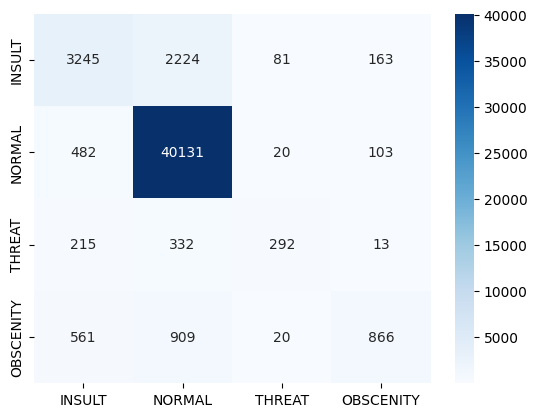

In [12]:
print_multiclass_metrics(y_test, y_pred_lgb)

#### f1-score macro for base params = 0.635
#### Подберем гиперпараметры с optuna

In [11]:
import lightgbm as lgb
import optuna

X_train, X_val, y_train, y_val = model_selection.train_test_split(X_train, y_train, test_size=TEST_SIZE, 
                                                                    random_state=RANDOM_SEED, stratify=y_train)

def objective(trial):

    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
        "verbosity": -1
    }

    model = LGBMClassifier(**params, objective="multiclass", num_class=4)

    model.fit(X_train, 
              y_train, 
              eval_set=[(X_val, y_val)],
              eval_metric="multi_logloss",
              callbacks=[
                lgb.early_stopping(100)
            ])
    

    preds = model.predict(X_test)
    # preds_proba = model.predict_proba(X_test)

    score = f1_score(y_test, preds, average='macro')

    return score

In [82]:
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=10, timeout=5200, show_progress_bar=True)

[I 2026-03-10 19:00:27,514] A new study created in memory with name: no-name-a1994b63-6e13-40d8-b562-96f22811b3ca


  0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1215]	valid_0's multi_logloss: 0.399756
[I 2026-03-10 19:01:02,013] Trial 0 finished with value: 0.40944718920722845 and parameters: {'learning_rate': 0.006258837793335747, 'n_estimators': 1215, 'max_depth': 1, 'num_leaves': 150, 'min_child_samples': 74, 'subsample': 0.9227901375085721, 'colsample_bytree': 0.6889883000554917, 'reg_alpha': 1.239028455508733e-06, 'reg_lambda': 1.8153145551117646e-08}. Best is trial 0 with value: 0.40944718920722845.
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[293]	valid_0's multi_logloss: 0.310466
[I 2026-03-10 19:03:21,225] Trial 1 finished with value: 0.636540340318966 and parameters: {'learning_rate': 0.011701997382504183, 'n_estimators': 293, 'max_depth': 12, 'num_leaves': 237, 'min_child_samples': 77, 'subsample': 0.7470599024792016, 'colsample_bytree': 0.8208373904347777, '

[I 2026-03-10 19:09:22,158] Trial 5 finished with value: 0.6707708591594166 and parameters: {'learning_rate': 0.019045048217950986, 'n_estimators': 1386, 'max_depth': 9, 'num_leaves': 188, 'min_child_samples': 11, 'subsample': 0.870707020270686, 'colsample_bytree': 0.9733896651915614, 'reg_alpha': 8.53841880770682, 'reg_lambda': 0.022841911801856362}. Best is trial 5 with value: 0.6707708591594166.

## LightGBM. w2v araneum + custom features

In [14]:
df_features = df.drop(columns=['label', 'comment', 'tokens', 'lemma_pos', 'feats'])

In [15]:
df_full = pd.concat([df_vectors, df_features], axis=1).drop(columns='is_normal')

In [16]:
X = df_full
y = df['label']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=TEST_SIZE, 
                                                                    random_state=RANDOM_SEED, stratify=y)
le = preprocessing.LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

standard_scaler = preprocessing.StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

X_train, X_val, y_train, y_val = model_selection.train_test_split(X_train, y_train, test_size=TEST_SIZE, 
                                                                    random_state=RANDOM_SEED, stratify=y_train)

In [17]:
def objective(trial):

    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
        "verbosity": -1
    }

    model = LGBMClassifier(**params, objective="multiclass", num_class=4)

    model.fit(X_train, 
              y_train, 
              eval_set=[(X_val, y_val)],
              eval_metric="multi_logloss",
              callbacks=[
                lgb.early_stopping(100)
            ])
    

    preds = model.predict(X_test)
    # preds_proba = model.predict_proba(X_test)

    score = f1_score(y_test, preds, average='macro')

    return score

In [16]:
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=150, timeout=1600, show_progress_bar=True)

[I 2026-04-01 13:04:33,577] A new study created in memory with name: no-name-0a1720d2-e643-471e-952d-6439853a78a9


  0%|          | 0/150 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[231]	valid_0's multi_logloss: 0.220096


/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2026-04-01 13:05:17,410] Trial 0 finished with value: 0.7105147242908461 and parameters: {'learning_rate': 0.14038281301879496, 'n_estimators': 425, 'max_depth': 12, 'num_leaves': 23, 'min_child_samples': 16, 'subsample': 0.8357923074240674, 'colsample_bytree': 0.6658116102703912, 'reg_alpha': 0.704385293211525, 'reg_lambda': 5.47460939347001}. Best is trial 0 with value: 0.7105147242908461.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[97]	valid_0's multi_logloss: 0.231446


...

[I 2026-04-01 13:29:33,661] Trial 9 finished with value: 0.6270996638918852 and parameters: {'learning_rate': 0.007775997384045591, 'n_estimators': 236, 'max_depth': 9, 'num_leaves': 158, 'min_child_samples': 33, 'subsample': 0.8937350930630534, 'colsample_bytree': 0.8292578966645927, 'reg_alpha': 2.487418869426237, 'reg_lambda': 4.146302274294902e-05}. Best is trial 0 with value: 0.7105147242908461.
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[85]	valid_0's multi_logloss: 0.240215


/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2026-04-01 13:30:46,394] Trial 10 finished with value: 0.6829397568301152 and parameters: {'learning_rate': 0.12700702524192756, 'n_estimators': 555, 'max_depth': 12, 'num_leaves': 100, 'min_child_samples': 6, 'subsample': 0.7965393287110476, 'colsample_bytree': 0.6801071278162703, 'reg_alpha': 0.09002846905077536, 'reg_lambda': 1.0212442687997525e-05}. Best is trial 0 with value: 0.7105147242908461.
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[686]	valid_0's multi_logloss: 0.219239


/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2026-04-01 13:32:37,104] Trial 11 finished with value: 0.7103164887311744 and parameters: {'learning_rate': 0.037519917360793464, 'n_estimators': 686, 'max_depth': 11, 'num_leaves': 22, 'min_child_samples': 71, 'subsample': 0.758560750825861, 'colsample_bytree': 0.6822103997067464, 'reg_alpha': 0.0010435285799506118, 'reg_lambda': 6.072477928963486e-08}. Best is trial 0 with value: 0.7105147242908461.


[I 2026-03-10 21:23:30,854] Trial 51 finished with value: 0.7978880304615186 and parameters: {'learning_rate': 0.05734300515864668, 'n_estimators': 1297, 'max_depth': 4, 'num_leaves': 141, 'min_child_samples': 10, 'subsample': 0.7464302640609062, 'colsample_bytree': 0.6051364316602454, 'reg_alpha': 0.002527868258341797, 'reg_lambda': 5.7794388794409235}. Best is trial 51 with value: 0.7978880304615186.


[I 2026-04-01 13:05:17,410] Trial 0 finished with value: 0.7105147242908461 and parameters: {'learning_rate': 0.14038281301879496, 'n_estimators': 425, 'max_depth': 12, 'num_leaves': 23, 'min_child_samples': 16, 'subsample': 0.8357923074240674, 'colsample_bytree': 0.6658116102703912, 'reg_alpha': 0.704385293211525, 'reg_lambda': 5.47460939347001}. Best is trial 0 with value: 0.7105147242908461.


In [ ]:
# params = {'learning_rate': 0.05734300515864668, 'n_estimators': 1297, 'max_depth': 4, 'num_leaves': 141, 'min_child_samples': 10, 'subsample': 0.7464302640609062, 'colsample_bytree': 0.6051364316602454, 'reg_alpha': 0.002527868258341797, 'reg_lambda': 5.7794388794409235}
params = study.best_params
model = LGBMClassifier(**params, objective="multiclass", num_class=4)

model.fit(X_train, 
            y_train, 
            eval_set=[(X_val, y_val)],
            eval_metric="multi_logloss",
            callbacks=[
            lgb.early_stopping(100)
        ])
print('fitted')
y_pred_lgb = model.predict(X_test)
print('predicted')
score = f1_score(y_test, y_pred_lgb, average='macro')
print(score)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[231]	valid_0's multi_logloss: 0.220096
fitted


/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


predicted
0.7105147242908461


f1 macro score: 0.7105147242908461
f1 weighted score: 0.9219619744480635
LR accurcay: 0.9275228064522625
              precision    recall  f1-score   support

      INSULT       0.79      0.76      0.77      5713
      NORMAL       0.95      0.99      0.97     40736
      THREAT       0.73      0.41      0.52       852
   OBSCENITY       0.74      0.47      0.58      2356

    accuracy                           0.93     49657
   macro avg       0.80      0.66      0.71     49657
weighted avg       0.92      0.93      0.92     49657



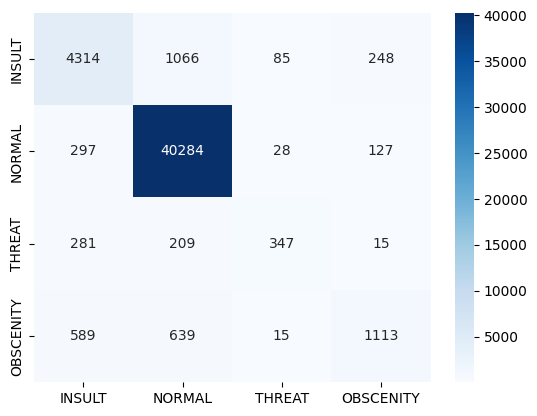

In [24]:
print_multiclass_metrics(y_test, y_pred_lgb)

## XGBoost. w2v araneum + custom features


f1 macro score: 0.7055322943490019
f1 weighted score: 0.920437214455756
LR accurcay: 0.9264554846245242
              precision    recall  f1-score   support

      INSULT       0.79      0.75      0.77      5713
      NORMAL       0.95      0.99      0.97     40736
      THREAT       0.76      0.39      0.52       852
   OBSCENITY       0.74      0.46      0.57      2356

    accuracy                           0.93     49657
   macro avg       0.81      0.65      0.71     49657
weighted avg       0.92      0.93      0.92     49657



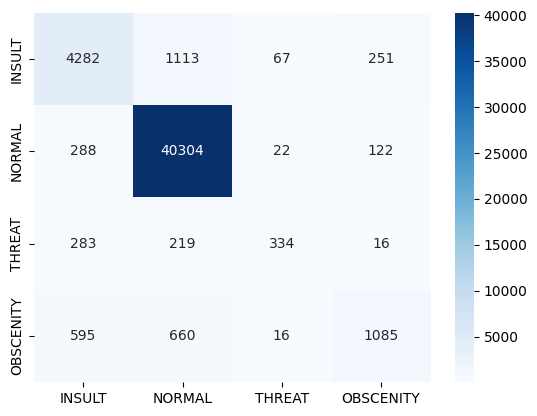

In [25]:
import xgboost as xgb
xb = xgb.XGBClassifier()
xb.fit(X_train, y_train)
y_pred_xb = xb.predict(X_test)

print_multiclass_metrics(y_test, y_pred_xb)

Learning rate set to 0.102466
0:	learn: 1.1703549	total: 310ms	remaining: 5m 9s
1:	learn: 1.0205761	total: 454ms	remaining: 3m 46s
2:	learn: 0.9103819	total: 629ms	remaining: 3m 28s
3:	learn: 0.8232954	total: 779ms	remaining: 3m 13s
4:	learn: 0.7542013	total: 936ms	remaining: 3m 6s
5:	learn: 0.6966707	total: 1.12s	remaining: 3m 4s
6:	learn: 0.6495615	total: 1.27s	remaining: 3m
7:	learn: 0.6095075	total: 1.4s	remaining: 2m 53s
8:	learn: 0.5745588	total: 1.56s	remaining: 2m 51s
9:	learn: 0.5448558	total: 1.7s	remaining: 2m 48s
10:	learn: 0.5190585	total: 1.86s	remaining: 2m 47s
11:	learn: 0.4967215	total: 2s	remaining: 2m 44s
12:	learn: 0.4775688	total: 2.13s	remaining: 2m 42s
13:	learn: 0.4602027	total: 2.3s	remaining: 2m 41s
14:	learn: 0.4455583	total: 2.43s	remaining: 2m 39s
15:	learn: 0.4330881	total: 2.56s	remaining: 2m 37s
16:	learn: 0.4210300	total: 2.69s	remaining: 2m 35s
17:	learn: 0.4106936	total: 2.83s	remaining: 2m 34s
18:	learn: 0.4012211	total: 2.99s	remaining: 2m 34s
19:	l

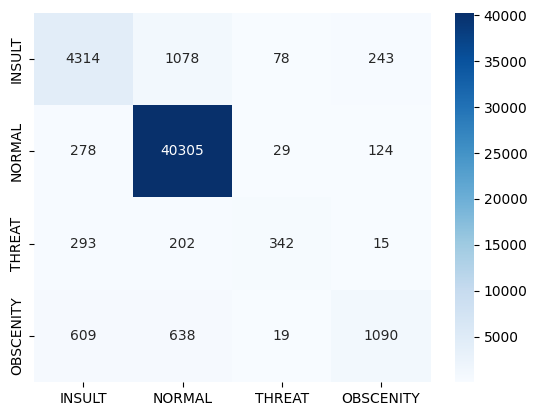

In [18]:
cb = CatBoostClassifier()
cb.fit(X_train, y_train)
y_pred_cb = cb.predict(X_test)

print_multiclass_metrics(y_test, y_pred_cb)

## Random Forest. w2v araneum + custom features

f1 macro score: 0.5282668756255142
f1 weighted score: 0.8573288548868037
LR accurcay: 0.8802585738163804
              precision    recall  f1-score   support

      INSULT       0.73      0.46      0.57      5713
      NORMAL       0.89      0.99      0.94     40736
      THREAT       0.79      0.16      0.27       852
   OBSCENITY       0.80      0.21      0.34      2356

    accuracy                           0.88     49657
   macro avg       0.80      0.46      0.53     49657
weighted avg       0.87      0.88      0.86     49657



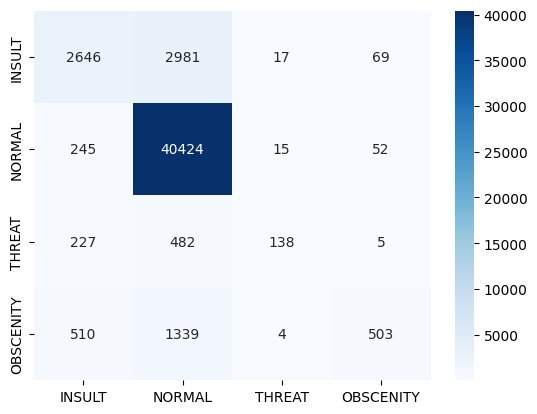

In [43]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print_multiclass_metrics(y_test, y_pred_rf)

### Итоги

| Признаки  | Модель | f1-macro |
|-------------|-------------|-------------|
| w2v |  LightGBM   | 0.636    |
| w2v + custom features    | LightGBM + optuna   | 0.711    |
| w2v + custom features      | CatBoost       | 0.706    |
| w2v + custom features      | XGBoost       | 0.707    |
| w2v + custom features      | RandomForest       | 0.529    |